In [26]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)  # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


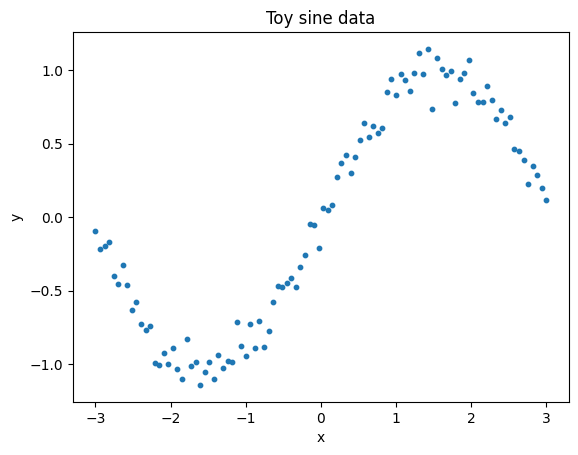

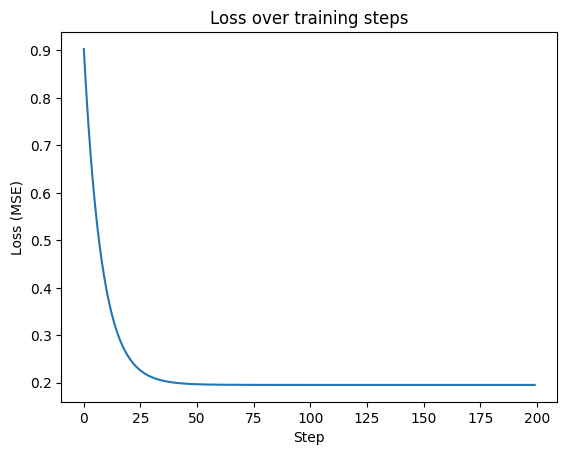

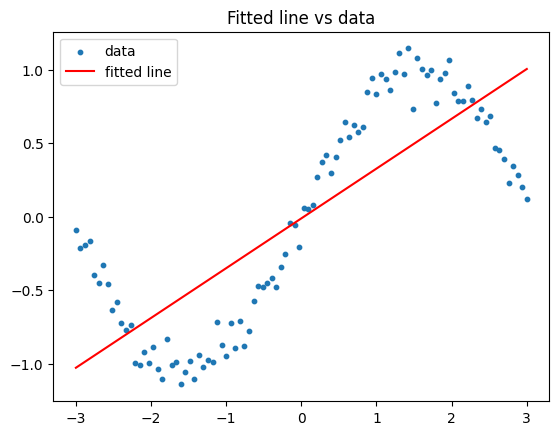

In [27]:
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

plt.scatter(x, y, s=10)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy sine data")
plt.show()

w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

lr = 0.01
n_steps = 200
losses = []

for step in range(n_steps):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))
    w -= lr * dw
    b -= lr * db
    losses.append(loss)


plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("Loss (MSE)")
plt.title("Loss over training steps")
plt.show()

plt.scatter(x, y, s=10, label="data")
plt.plot(x, w * x + b, color="red", label="fitted line")
plt.legend()
plt.title("Fitted line vs data")
plt.show()

Yes the derivation matches the code directly.
dw = np.mean(2 * (y_hat - y) * x)
db = np.mean(2 * (y_hat - y))

This is underfitting.
Overfitting means the model is complex enough to chase the noise in the training data, giving low training loss but poor generalization. That's not what's happening here the training loss itself plateaus at a high value and never gets low, no matter how long it is trained.
A single neuron with no nonlinearity computes ŷ = w·x + b, as the equation of a straight line. The entire set of functions this model can ever represent is "all possible straight lines." A sine wave is periodic and non-monotonic (it goes up, then down, then up again), and no straight line can capture that shape not for any values of w and b.
Gradient descent isn't the limitation here. It successfully finds the best straight line that's why the loss curve flattens out. But the "best line" is still a terrible fit to a curve, because the model's hypothesis space (the family of functions it can represent) doesn't contain anything resembling a sine wave. Training longer only gets you closer to the best line already available; it can't expand what shapes are available to fit. That's the hallmark of underfitting caused by insufficient model capacity, not insufficient training.

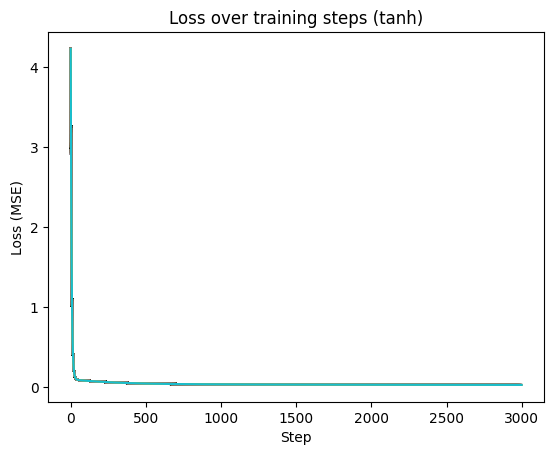

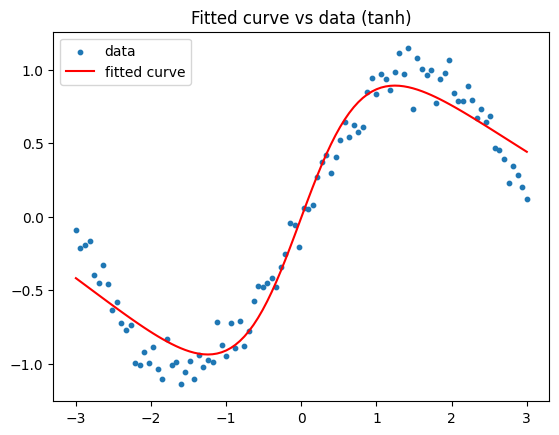

In [28]:
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

z1 = x @ W1 + b1
h = np.tanh(z1)
y_hat = h @ W2 + b2
loss = np.mean((y_hat - y) ** 2)

d_yhat = 2 * (y_hat - y) / len(y)
dW2 = h.T @ d_yhat
db2 = d_yhat.sum(axis=0)
dh = d_yhat @ W2.T
dz1 = dh * (1 - np.tanh(z1) ** 2)
dW1 = x.T @ dz1
db1 = dz1.sum(axis=0)

lr = 0.01
n_steps = 3000
losses = []

for step in range(n_steps):
    z1 = x @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y) ** 2)

    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

    losses.append(loss)

    plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("Loss (MSE)")
plt.title("Loss over training steps (tanh)")
plt.show()

plt.scatter(x, y, s=10, label="data")
plt.plot(x, y_hat, color="red", label="fitted curve")
plt.legend()
plt.title("Fitted curve vs data (tanh)")
plt.show()

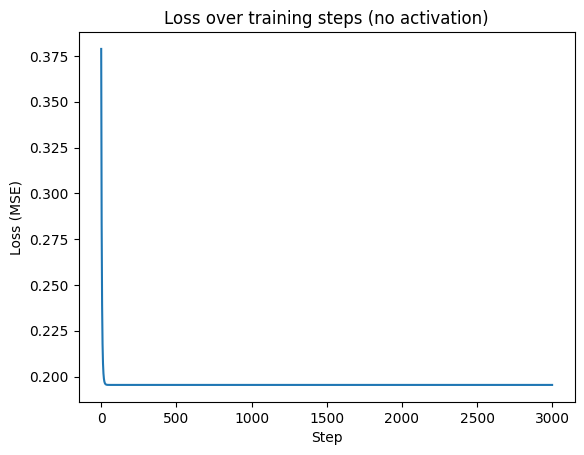

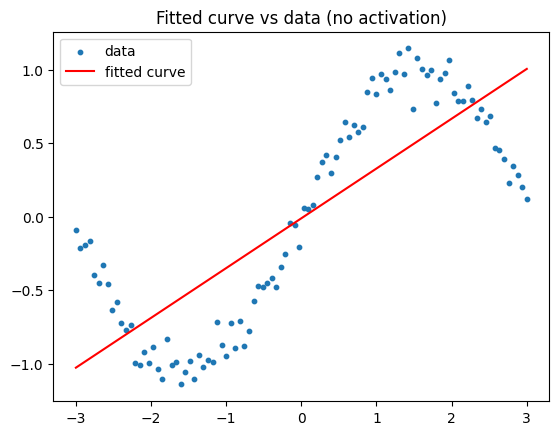

In [29]:
W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

losses_no_activation = []

for step in range(n_steps):
    z1 = x @ W1 + b1
    h = z1
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y) ** 2)

    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2.T
    dz1 = dh
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

    losses_no_activation.append(loss)

plt.plot(losses_no_activation)
plt.xlabel("Step")
plt.ylabel("Loss (MSE)")
plt.title("Loss over training steps (no activation)")
plt.show()

plt.scatter(x, y, s=10, label="data")
plt.plot(x, y_hat, color="red", label="fitted curve")
plt.legend()
plt.title("Fitted curve vs data (no activation)")
plt.show()

There was no activation where W' = W1 @ W2 and b' = b1 @ W2 + b2 are just fixed vectors. This has the exact same form as y_hat = w*x + b a composition of linear functions is itself linear, no matter how many layers you stack. The nonlinearity (tanh) is what stops this collapse.
Each column of h is a tanh-shaped ("S-curve") function of x, but shifted and stretched differently depending on that neuron's own W1/b1 values. So the 8 neurons act as 8 different bent basis-curves. The output layer then just takes a weighted sum of those 8 curves (h @ W2 + b2), and by weighting each curve differently, the network can combine them to approximate the shape of the sine wave something no single straight line could do.
Backpropagation is the systematic application of the chain rule to compute the gradient of the loss with respect to every parameter in the network, layer by layer, by propagating error signals backward from the output to the input.

C:\Users\Hp\AppData\Local\Temp\ipykernel_4388\701471573.py:14: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
C:\Users\Hp\AppData\Local\Temp\ipykernel_4388\701471573.py:19: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
C:\Users\Hp\AppData\Local\Temp\ipykernel_4388\701471573.py:20: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)


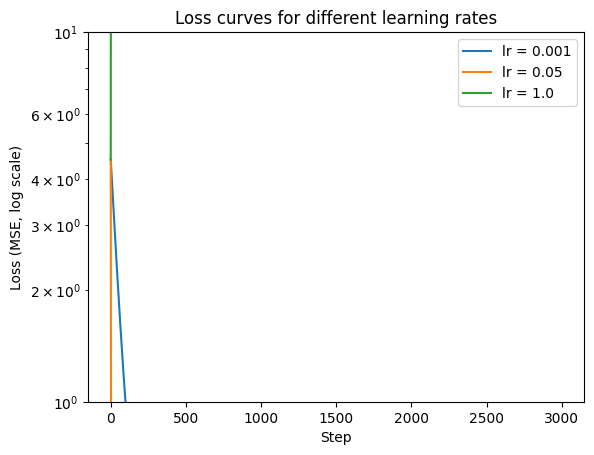

In [30]:
def train_toy(lr, steps=3000):
    np.random.seed(RANDOM_STATE)
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.random.randn(8) * 0.5
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.random.randn(1) * 0.5

    losses = []

    for step in range(steps):
        z1 = x @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - y) ** 2)

        d_yhat = 2 * (y_hat - y) / len(y)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)

        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

        losses.append(loss)

    return losses


lrs = [0.001, 0.05, 1.0]
loss_curves = {lr: train_toy(lr) for lr in lrs}

plt.figure()
for lr in lrs:
    plt.plot(loss_curves[lr], label=f"lr = {lr}")
plt.yscale("log")
plt.xlabel("Step")
plt.ylabel("Loss (MSE, log scale)")
plt.title("Loss curves for different learning rates")
plt.legend()
plt.show()

What the curves shows:
lr = 0.001 (blue): Loss decreases, but slowly and steadily  it takes approximately 100+ steps to approach near zero. This is the "too cold" regime: safe but slow, wasting most of the 3000 steps doing very little once it's converged.
lr = 0.05 (orange): Loss drops sharply within the first approximate 50 steps and settles low. This is the "just right" regime  fast, smooth convergence.
lr = 1.0 (green): Loss immediately shoots up and stays pinned near the top of the plot  it diverged rather than converged. This is "too hot."
Gradient descent takes a step of size lr * gradient in the direction that reduces loss but the loss surface is curved, and that gradient is only a local, linear approximation valid for small steps. If lr is too large, the step overshoots past the minimum entirely, landing on a point where the loss is now higher than before, with an even steeper gradient. The next update then overshoots again, even more violently  each step amplifies the error rather than correcting it, so the loss grows unboundedly  instead of settling down. It's not "learning faster," because the update is no longer tracking the actual shape of the loss surface it's jumping wildly based on a linear approximation that's no longer valid at that step size.

In [31]:
# SECTION 2
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)


# Binary yes/no - 0/1
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binary_cols:
    obesity[col] = obesity[col].map({"yes": 1, "no": 0})

# Ordinal encoding for CAEC and CALC (natural order: no < Sometimes < Frequently < Always)
ordinal_map = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
obesity["CAEC"] = obesity["CAEC"].map(ordinal_map)
obesity["CALC"] = obesity["CALC"].map(ordinal_map)

# One-hot encoding for Gender and MTRANS
obesity = pd.get_dummies(obesity, columns=["Gender", "MTRANS"])

# Encode target into integers 0..6
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(obesity["NObeyesdad"])
X = obesity.drop(columns=["NObeyesdad"]).astype(float)


from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [32]:
print(X_train_tensor.shape, y_train_tensor.shape)
print(X_val_tensor.shape, y_val_tensor.shape)
print(X_test_tensor.shape, y_test_tensor.shape)
print("Number of classes:", len(target_encoder.classes_))

torch.Size([1266, 21]) torch.Size([1266])
torch.Size([422, 21]) torch.Size([422])
torch.Size([423, 21]) torch.Size([423])
Number of classes: 7


PyTorch's CrossEntropyLoss internally combines log_softmax + negative log-likelihood in one fused operation. Given an integer label y, it directly indexes the log-probability of the correct class (-log_softmax(y_hat)[y]) rather than computing a full dot product with a one-hot vector. This is mathematically equivalent to using one-hot labels, but avoids storing a redundant sparse vector and is computed more efficiently and numerically stably in a single fused op so PyTorch's API expects the compact integer form instead.

A random forest splits on thresholds ("is Age > 25?")  it only cares about the order of values in a feature, not their magnitude, so rescaling doesn't change any split decision. Neural networks, by contrast, learn via gradient descent, and as in Section 1: dw = mean(2*(y_hat - y)*x) the gradient for each weight is directly proportional to its input x. If one feature (e.g., Weight, ranging 0–170) is on a much larger scale than another (e.g., a 0/1 binary flag), its gradient dominates the update, making training slow, unstable, or biased toward large-scale features. Scaling every feature to a similar range (mean 0, std 1) keeps all gradients on a comparable scale, so gradient descent converges evenly across all weights.

It randomizes the order examples are drawn into batches at the start of every epoch, so each mini-batch is a fresh, independent random sample of the training set rather than the same fixed sequence each time. This prevents the model from learning spurious patterns tied to data ordering (e.g., if the CSV is sorted by class), and it means the noisy gradient estimate from each mini-batch varies run to run  which helps gradient descent avoid getting stuck in a rut and generally leads to better generalization than a fixed batch order.

In [33]:
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_sizes[0])
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.fc3 = nn.Linear(hidden_sizes[1], n_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x


input_dim = X_train_tensor.shape[1]
model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=7)
model = model.to(DEVICE)
print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total trainable parameters:", total_params)

# Verify first layer by hand
first_layer_params = input_dim * 64 + 64
print("First layer parameters (input_dim * 64 + 64):", first_layer_params)

FeedForwardNet(
  (fc1): Linear(in_features=21, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=7, bias=True)
  (relu): ReLU()
)
Total trainable parameters: 3719
First layer parameters (input_dim * 64 + 64): 1408


By-hand parameter count for every layer
fc1: 21 × 64 + 64 = 1408
fc2: 64 × 32 + 32 = 2080
fc3: 32 × 7 + 7 = 231
Total: 1408 + 2080 + 231 = 3719 
ReLU doesn't saturate for positive inputs (its gradient is a constant 1 there), whereas tanh squashes large inputs toward ±1 and its gradient shrinks toward 0 in that region. This means ReLU avoids the vanishing-gradient problem that gets worse as networks get deeper, so gradients flow back through many layers more reliably during training.
As shown in Part 1.2, stacking linear layers with no nonlinearity between them collapses into a single linear transformation  so the whole network would just compute y_hat = x @ W' + b' for some combined W' and b', equivalent to one linear layer no matter how many layers you stack.

Epoch   1/50 | train_loss=1.7378 train_acc=0.4518 | val_loss=1.7396 val_acc=0.4573
Epoch   2/50 | train_loss=1.3453 train_acc=0.5561 | val_loss=1.3632 val_acc=0.5640
Epoch   3/50 | train_loss=1.0251 train_acc=0.6596 | val_loss=1.0721 val_acc=0.6303
Epoch   4/50 | train_loss=0.8349 train_acc=0.7299 | val_loss=0.9302 val_acc=0.6848
Epoch   5/50 | train_loss=0.7082 train_acc=0.7678 | val_loss=0.8480 val_acc=0.7133
Epoch   6/50 | train_loss=0.6193 train_acc=0.8009 | val_loss=0.7909 val_acc=0.7512
Epoch   7/50 | train_loss=0.5409 train_acc=0.8318 | val_loss=0.7376 val_acc=0.7773
Epoch   8/50 | train_loss=0.4782 train_acc=0.8531 | val_loss=0.7013 val_acc=0.7749
Epoch   9/50 | train_loss=0.4271 train_acc=0.8784 | val_loss=0.6758 val_acc=0.8081
Epoch  10/50 | train_loss=0.3800 train_acc=0.8926 | val_loss=0.6410 val_acc=0.8175
Epoch  11/50 | train_loss=0.3383 train_acc=0.9068 | val_loss=0.6153 val_acc=0.8199
Epoch  12/50 | train_loss=0.3063 train_acc=0.9092 | val_loss=0.5941 val_acc=0.8365
Epoc

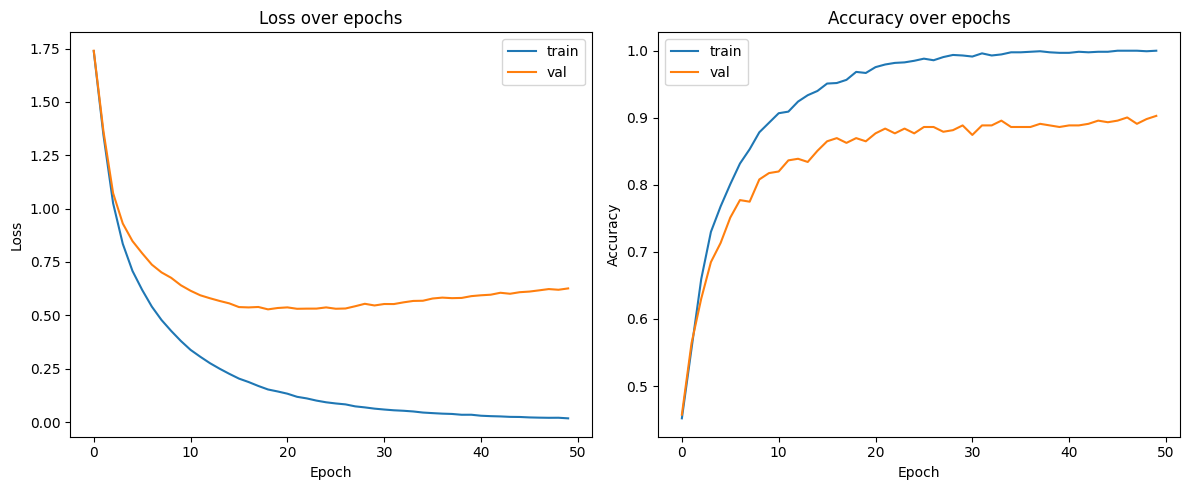

In [34]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)
    return total_loss / total, correct / total


n_epochs = 50

train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0.0

for epoch in range(n_epochs):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

    train_loss, train_acc = evaluate(model, train_loader, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch + 1:3d}/{n_epochs} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "ffn_best.pt")

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(train_losses, label="train")
axes[0].plot(val_losses, label="val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss over epochs")
axes[0].legend()

axes[1].plot(train_accs, label="train")
axes[1].plot(val_accs, label="val")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy over epochs")
axes[1].legend()

plt.tight_layout()
plt.show()

Mapping PyTorch loop to Section 1:
Forward pass: logits = model(xb) ->  y_hat = w * x + b (or z1 = x@W1+b1; h = tanh(z1); y_hat = h@W2+b2)
Loss: loss = criterion(logits, yb) ->  loss = np.mean((y_hat - y) ** 2)
Gradient computation: loss.backward() ->  dw, db (or dW1, db1, dW2, db2)  autograd computes these automatically via the chain rule instead of you deriving them by hand
Update rule: optimizer.step() ->  w -= lr * dw; b -= lr * db  Adam's internal update rule generalizes this same "subtract lr times gradient" idea
Overfitting. Train loss drops to approximate 0.02 and train accuracy reaches approximate 100%, while val loss bottoms out around 0.53 near epoch 15 then rises back to approximate 0.62, and val accuracy plateaus around  approximately 90% without improving further. The widening gap between near-perfect training performance and stalled/worsening validation performance after epoch approximate 15 is the signature of overfitting.
PyTorch accumulates gradients into .grad by default rather than overwriting them each loss.backward() call adds to whatever's already there. Without zeroing first, gradients from previous batches would keep piling up on top of the current batch's gradients, so each optimizer.step() would apply an update based on a growing sum across many batches instead of just the current one silently corrupting training with ever-larger, incorrect gradient magnitudes.

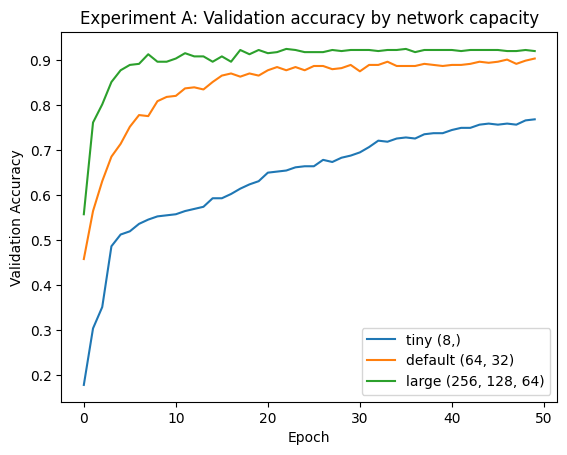

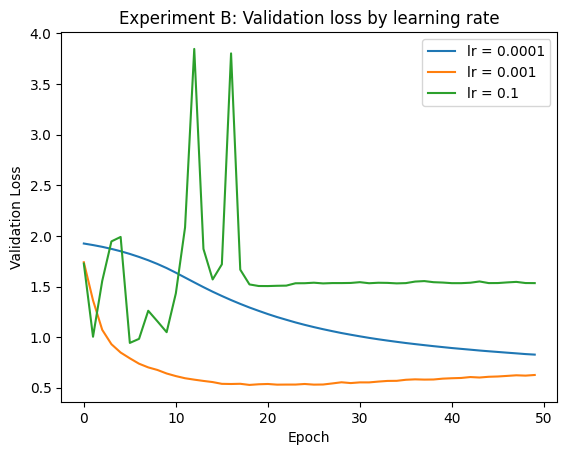

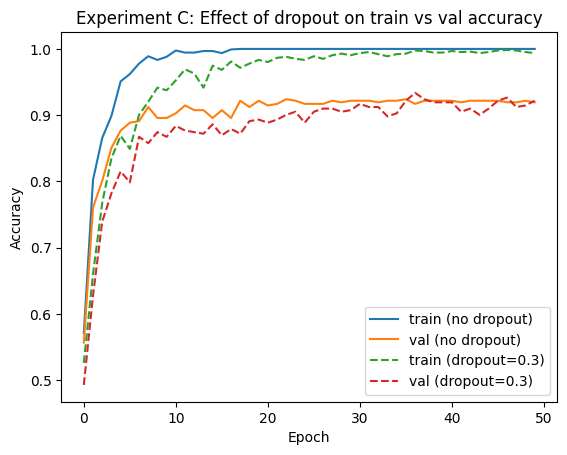

In [ ]:
class FlexFeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0):
        super().__init__()
        layers = []
        prev_size = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_size = h
        layers.append(nn.Linear(prev_size, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def run_experiment(
    hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0
):
    torch.manual_seed(RANDOM_STATE)

    local_train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    local_val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model = FlexFeedForwardNet(
        input_dim=X_train_tensor.shape[1],
        hidden_sizes=hidden_sizes,
        n_classes=7,
        dropout=dropout,
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        for xb, yb in local_train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        train_loss, train_acc = evaluate(model, local_train_loader, criterion)
        val_loss, val_acc = evaluate(model, local_val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

    return history


architectures = {
    "tiny (8,)": (8,),
    "default (64, 32)": (64, 32),
    "large (256, 128, 64)": (256, 128, 64),
}

history_capacity = {
    name: run_experiment(hidden_sizes=hs) for name, hs in architectures.items()
}

plt.figure()
for name, history in history_capacity.items():
    plt.plot(history["val_acc"], label=name)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Experiment A: Validation accuracy by network capacity")
plt.legend()
plt.show()


lrs = [1e-4, 1e-3, 1e-1]

history_lr = {lr: run_experiment(hidden_sizes=(64, 32), lr=lr) for lr in lrs}

plt.figure()
for lr, history in history_lr.items():
    plt.plot(history["val_loss"], label=f"lr = {lr}")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Experiment B: Validation loss by learning rate")
plt.legend()
plt.show()


largest_hidden = (256, 128, 64)

history_no_dropout = run_experiment(hidden_sizes=largest_hidden, dropout=0.0)
history_dropout = run_experiment(hidden_sizes=largest_hidden, dropout=0.3)

plt.figure()
plt.plot(history_no_dropout["train_acc"], label="train (no dropout)")
plt.plot(history_no_dropout["val_acc"], label="val (no dropout)")
plt.plot(history_dropout["train_acc"], label="train (dropout=0.3)", linestyle="--")
plt.plot(history_dropout["val_acc"], label="val (dropout=0.3)", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Experiment C: Effect of dropout on train vs val accuracy")
plt.legend()
plt.show()

Capacity: Yes  the large network (256,128,64) reaches the highest validation accuracy (~0.92), beating default (~0.90) and tiny (~0.77). But diminishing returns show up between default and large: default already gets to ~0.90, so the large network's extra capacity only buys ~2 more percentage points, not a proportional jump. There's no clear overfitting signal in this specific plot (validation accuracy for large keeps climbing, not dropping), but the small gap between default and large suggests capacity isn't the bottleneck anymore at that size.
Learning rate: Yes, it matches Part 1.3 closely. lr=1e-3 is the "just right" regime fast, smooth convergence to the lowest loss. lr=1e-4 is "too cold" steady but slow, still improving at epoch 50. lr=1e-1 is "too hot" visible instability with sharp spikes (up to ~3.8 loss) before settling at a worse final loss than the other two, mirroring the divergence seen with lr=1.0 on the toy problem.
Regularization: Dropout narrowed the train-validation gap  without it, train accuracy hit ~100% while val stalled at ~90-92% (a large gap); with dropout=0.3, train stayed slightly lower (~98-99%) and tracked much closer to validation (~90-93%). Dropout works by randomly zeroing a fraction of neurons on each forward pass during training, which prevents the network from relying too heavily on any single neuron or fixed co-adapted pathway, forcing it to learn more redundant, generalizable features instead of memorizing the training set.

Test Accuracy: 0.9149
Test Macro-F1: 0.9132

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.91      0.95        54
      Normal_Weight       0.77      0.79      0.78        58
     Obesity_Type_I       0.97      0.94      0.96        70
    Obesity_Type_II       1.00      0.95      0.97        60
   Obesity_Type_III       0.98      1.00      0.99        65
 Overweight_Level_I       0.80      0.81      0.80        58
Overweight_Level_II       0.89      0.98      0.93        58

           accuracy                           0.91       423
          macro avg       0.92      0.91      0.91       423
       weighted avg       0.92      0.91      0.92       423



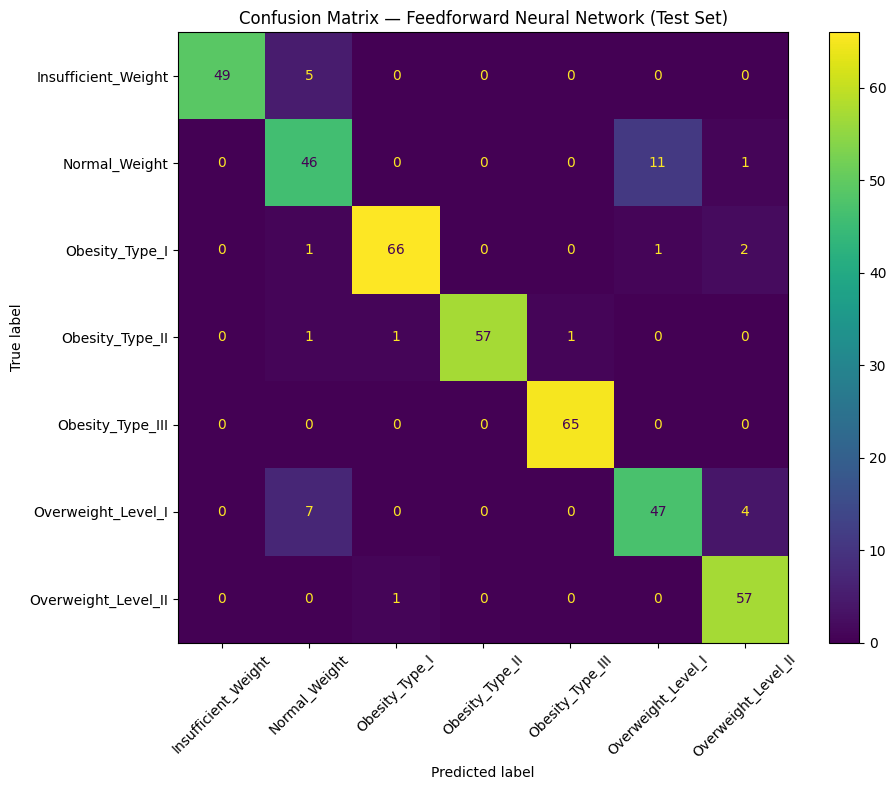

In [ ]:
best_model = FeedForwardNet(
    input_dim=X_train_tensor.shape[1], hidden_sizes=(64, 32), n_classes=7
).to(DEVICE)
best_model.load_state_dict(torch.load("ffn_best.pt"))
best_model.eval()

from sklearn.metrics import accuracy_score, f1_score, classification_report

all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        logits = best_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

test_accuracy = accuracy_score(all_labels, all_preds)
test_macro_f1 = f1_score(all_labels, all_preds, average="macro")

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Macro-F1: {test_macro_f1:.4f}")
print("\nClassification Report:")
print(
    classification_report(all_labels, all_preds, target_names=target_encoder.classes_)
)

from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    all_labels,
    all_preds,
    display_labels=target_encoder.classes_,
    xticks_rotation=45,
    ax=ax,
)
plt.title("Confusion Matrix — Feedforward Neural Network (Test Set)")
plt.tight_layout()
plt.show()

In [ ]:
import time

# Time the neural network's training for a fair comparison
start_time = time.time()
history_final = run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50)
nn_training_time_seconds = time.time() - start_time

nn_num_params = sum(p.numel() for p in best_model.parameters() if p.requires_grad)

comparison_df = pd.DataFrame(
    {
        "Model": ["Random Forest (Lab 2)", "Feedforward Neural Network"],
        "Test Accuracy": [0.9764, test_accuracy],
        "Test Macro-F1": [0.9759, test_macro_f1],
        "Training Time (s)": [
            None,
            nn_training_time_seconds,
        ],  # My Lab 2 didn't measure this
        "Params / Trees": [100, nn_num_params],  # RF used default n_estimators=100
    }
)

comparison_df

,Model,Test Accuracy,Test Macro-F1,Training Time (s),Params / Trees
0,Random Forest (Lab 2),0.976400,0.975900,NaN,100
1,Feedforward Neural Network,0.914894,0.913173,17.999174,3719


Yes, same general pattern. Lab 2's Random Forest confused Insufficient_Weight -Normal_Weight, Overweight_Level_I - Normal_Weight, Overweight_Level_II - Normal_Weight, and Obesity_Type_II - Obesity_Type_III all adjacent-category mix-ups. The neural network shows the exact same adjacent-class pattern (Normal_Weight - Overweight_Level_I is now its biggest error, 11 misclassifications), but with noticeably more total errors  its weaker overall accuracy shows up as more confusion within that same boundary region, not new confusion elsewhere.
Random Forest wins clearly  with 0.9764 vs 0.9149 test accuracy. On this dataset, deep learning was not worth the extra effort: tabular data with only ~1700 training rows and 21 features is exactly the regime where tree ensembles excel (they handle mixed categorical/numeric features and non-linear interactions natively, with far less tuning and no risk of the instability/overfitting sensitivity you saw in the LR experiments). A neural network's advantage shows up when we have much larger datasets (tens of thousands+ rows), unstructured data (images, text, audio) where trees can't exploit spatial/sequential structure, or when you need representation learning rather than a fixed feature table none of which apply here.

REFLECTION

1. The black box, opened: loss.backward() applies the chain rule automatically, propagating the error signal backward from the loss through every layer to compute the gradient of the loss with respect to every weight and bias the same derivatives by hand in Section 1, just automated. It also accumulates these gradients into each parameter's .grad attribute. optimizer.step() then uses those gradients to update every parameter (param -= lr * gradient, adjusted by Adam's momentum/adaptive scaling), moving the model one step toward lower loss.
2. One hyperparameter to tune: Learning rate. It has the most immediate, dramatic effect on training too high and the model diverges or oscillates, too low and training barely progresses in a reasonable time. Almost every other hyperparameter (architecture size, dropout) only matters if training itself is stable, and lr controls that stability directly.
3. Biggest overfitting gap: The largest train-vs-validation gap appeared in Experiment C's no-dropout run  train accuracy hit ~100% while validation plateaued around 90%. Adding dropout=0.3 reduced this gap the most, pulling train accuracy down slightly (~98-99%) while validation stayed similar, closing most of the difference.
4. Looking ahead  why MLPs struggle with images: A plain MLP flattens an image into a single long vector and treats every pixel as an independent, unrelated feature it has no built-in notion that two neighboring pixels are usually related (edges, textures, shapes), so it must re-learn spatial patterns separately for every possible position in the image. A better architecture should have spatial locality and translation invariance built in i.e., it should look at small local neighborhoods of pixels and detect the same pattern regardless of where it appears in the image (which is exactly what convolutional layers provide).